# CROSS VALIDATION
- To gurantee robustness of a model, a modeler must perform cross validation. 
- Cross validation ensures that the model does not make predictions by chance.

## Over-fitting and Under-fitting
- In over-fitting, a model performs very well during training (low-bias) but poorly during testing (high variance). The model therefore fails to generalize on unseen data (very complex model)<br><br>
- In under-fitting, a model performs poorly on both training and testing sets. The model does not generalize on both unseen and training data.<br><br>
- An ideal model is one that does not overfit/underfit but generalizes during training.

<img src="over_under.png" width=700>

- If training score is much bigger than the testing score, this is a flag for overfitting <br><br>
- Lower training and testing scores point to an underfitting model

## K-fold Cross-validation
- This method resuses the training data as validation data <br><br>
- The data is split into `k` portions (folds).<br><br>
- Each fold serves as test data once and the rest as training data <br><br>
- The result is a table of `k` scores for each fold.<br><br>
- The `k` scores should not deviate much from each other for a robust model<br><br>

<img src="crossval.png" width=600>

## 1 Define Business goal
- To train a logistic regression model that predicts survived/dead passengers from the titanic data using passenger class and Sex

In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedShuffleSplit

## 2. Get data

In [60]:
df = pd.read_csv("train.csv")

In [61]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


### 2.1 Isolate the features

In [62]:
df_subset = df[["Survived", "Pclass", "Sex"]]

### 2.2 Define/Assign X and y

In [63]:
X = df_subset.drop("Survived", axis=1)
y = df_subset["Survived"]

In [64]:
X.head()

,Pclass,Sex
0,3,male
1,1,female
2,3,female
3,1,female
4,3,male


In [65]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

## 3 Train-Test-Split

In [66]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, random_state=42, test_size=0.2)

## 4 Explore the data
Be creative!<br><br>

- Check for missing data<br><br>
- Plot all the things!<br><br>
    - sns.pairplot()<br><br>
    - df.corr()<br><br>
**Remember**<br><br>
- Do data exploration on training data only! That means you have two options:<br><br>

    - merge your X_train and y_train from the previous step<br><br>
    - run train_test_split() on full dataframe with same test size and random state<br><br>

## 5 Feature Engineering
- Remember this is the part that makes or breaks the machine learning model<br><br>
- Feature Engineering sets out to establish the right representation of your input data<br><br>
    - which features help me build a better model?<br><br>
    - How should I format them to include them into the model<br><br>    

## 6 Train the Model
- We shall impute and one hot encode Pclass and Sex and then train the model in a pipeline

- categorical features

In [71]:
categorical_features = ["Pclass", "Sex"]

- impute and OHE

In [69]:
pipe = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(sparse_output=False, drop="first")    
)

In [70]:
pipe

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                ('onehotencoder',
                 OneHotEncoder(drop='first', sparse_output=False))])

- Transform the columns as a preprocessing step

In [72]:
preprocessor = ColumnTransformer(
    
    [
        ("ohe", pipe, categorical_features)
    ]

)

In [73]:
preprocessor

ColumnTransformer(transformers=[('ohe',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False))]),
                                 ['Pclass', 'Sex'])])

- Define the classifier

In [74]:
classifier = LogisticRegression()

- Train the model now in a pipeline

In [75]:
model = make_pipeline(
    preprocessor, # First step where we modify our data
    classifier # Run the model using the results from the previous step
)

### 6.1 Scores

In [77]:
model.fit(Xtrain, ytrain)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('ohe',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['Pclass', 'Sex'])])),
                ('logisticregression', LogisticRegression())])

In [78]:
model.score(Xtrain, ytrain)

0.7879213483146067

In [79]:
model.score(Xtest, ytest)

0.7821229050279329

In [81]:
pipe.fit(Xtrain)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                ('onehotencoder',
                 OneHotEncoder(drop='first', sparse_output=False))])

- training score is slightly higher than the testing score but not too bad. <br><br>
- Is there an overfit? <br><br>
    - We find out through cross-validation<br><br>
- We shall use a `k=5` or 5 folds <br><br>

In [97]:
cv_scores_with_kfold = cross_val_score(estimator=model, X=Xtrain, y=ytrain, cv=5, scoring="accuracy")

In [98]:
cv_scores_with_kfold

array([0.7972028 , 0.81118881, 0.75352113, 0.75352113, 0.82394366])

**The mean cross-validation score**

In [99]:
np.mean(cv_scores_with_kfold)

0.7878755047769133

### Interpretation of results:
- If training score >> mean(validation_scores), you might be overfitting!<br><br>
- If training score << mean(validation_scores), you might be underfitting!<br><br>
- If there is high variation in the validation scores, then you have high sampling bias!<br><br>
- If you do have high sampling bias (i.e. large variation in validation scores, you probably need more data, pick a different model, change hyperparameters). <br><br>

**What do we observe?**
- The mean cross-validated score is somehow near the training score but slightly higher than the testing score.<br><br>
- Perhaps we need to do more feature engineering using the best representative features. <br><br>
- Once we are satisfied that the bias in the training data is low, we can proceed with the next steps<br><br>



### Cross validation using `shuffle-split` instead of `k-folds`
- `shuffle-split` shuffles the data and collects a representative sample of a specific specified size.

- Create 5 splits with a test_size of 20%

In [110]:
ss = StratifiedShuffleSplit(n_splits=5, test_size=.2, random_state=42)

- Peform cross validation

In [111]:
cv_scores_with_shuffle_split = cross_val_score(estimator=model, X=Xtrain, y=ytrain, cv=ss, scoring="accuracy")

- Examine the scores

In [112]:
cv_scores_with_shuffle_split

array([0.81818182, 0.7972028 , 0.74825175, 0.8041958 , 0.78321678,
       0.74125874, 0.82517483, 0.7972028 , 0.82517483, 0.81818182,
       0.77622378, 0.78321678, 0.83216783, 0.8041958 , 0.74825175,
       0.8041958 , 0.85314685, 0.83916084, 0.73426573, 0.81818182])

`shufflesplit` tends to be more robust than `kfold` due to randomisation of samples

### Calculate the mean of the scores

In [113]:
np.mean(cv_scores_with_shuffle_split)

0.7975524475524477

## TODO: Check on Bootstrapping from the online notes and compare with the kfolds and stratified shuffle split
- Note: Bootstrap is more like the big brother of cross-validation (3.8.4 in the online notes)

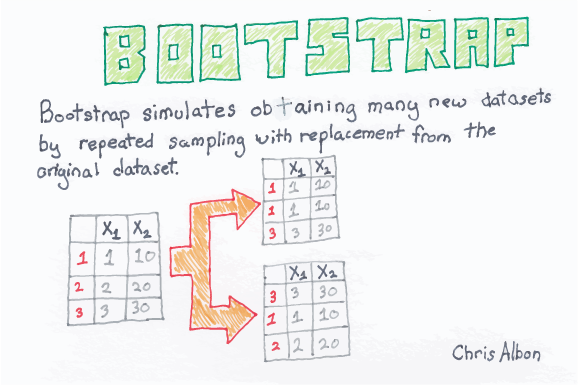

- After Cross-validation, you can then proceed to make your predictions!!